In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import rasterio.plot as rplt
import cmocean as cmo

In [2]:
dmg_path = r"D:\PhD\21_Experiments\TidesDamageDriver\02_processed\NeRD\2024"
img_base = r"tile-182_S1_20241101_20241110_30m_output_10px"

In [3]:
img_name_dmg = os.path.join(dmg_path, img_base + "_dmg.tif")
img_name_crev = os.path.join(dmg_path, img_base + "_crevSig.tif")
img_name_alphaC = os.path.join(dmg_path, img_base + "_alphaC.tif")
img_name_emax = os.path.join(dmg_path, img_base + "_emax.tif")
img_name_angle = os.path.join(dmg_path, img_base + "_delta-alpha.tif")
img_name_act = os.path.join(dmg_path, img_base + "_act.tif")

In [4]:
tiles = []
transform = []

for img_name in [img_name_crev, img_name_dmg, img_name_alphaC, img_name_emax, img_name_angle, img_name_act]:
    with rio.open(img_name) as src:
        tiles.append(src.read(1))
        transform.append(src.transform)

In [5]:
np.nanmin(tiles[1])

np.float64(7.740623350627196e-09)

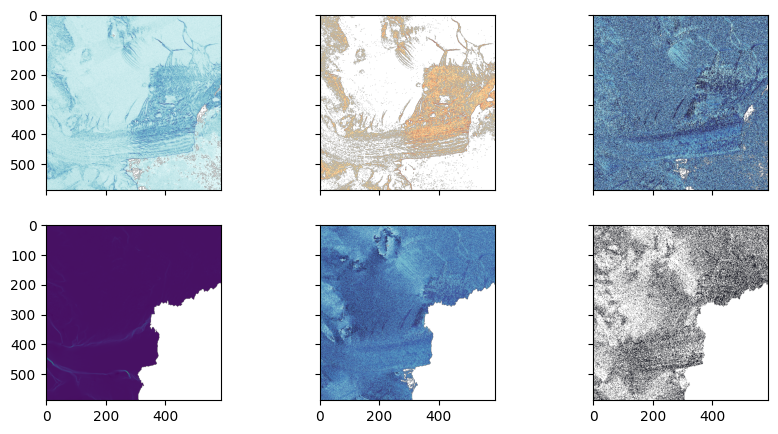

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5), sharex=True, sharey=True)

# [-100:, :100]
axs = axes.ravel()
rplt.show(tiles[0], ax=axs[0], cmap="cmo.ice_r")
rplt.show(tiles[1], ax=axs[1], cmap="cmo.matter", vmin=0, vmax=0.5)
rplt.show(tiles[2], ax=axs[2], cmap="cmo.ice_r")
rplt.show(tiles[3], ax=axs[3], cmap="viridis")
rplt.show(tiles[4], ax=axs[4], cmap="cmo.ice")
rplt.show(tiles[5], ax=axs[5], cmap="cmo.ice")
plt.show()